# Phase 6 — Feature Engineering

This notebook reproduces the deterministic feature-engineering pipeline, shows the final model-specific matrices, and documents retained and rejected proposals. No target is used to construct predictors, and no split or model fitting occurs.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLBACKEND', 'Agg')
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').is_file())
sys.path.insert(0, str(project_root / 'src'))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from finaccess_eswatini.phase6_feature_engineering import run

summary = run()
report_dir = project_root / 'reports' / 'phase_6'
matrix_summary = pd.DataFrame([
    {
        'Model': model,
        'Target': details['target'],
        'Rows': details['rows'],
        'Final predictors': details['feature_count'],
        'Null cells': details['null_cells'],
        'Output': details['output_file'],
    }
    for model, details in summary['models'].items()
])
display(matrix_summary)
print('Target used in feature derivation:', summary['engineering']['target_used_in_derivation'])
print('Models trained:', summary['models_trained'])

,Model,Target,Rows,Final predictors,Null cells,Output
0,model1,account_fin,1051,15,0,data/processed/model1_financial_inclusion_fina...
1,model2,account_mob,1051,16,0,data/processed/model2_mobile_money_final.csv


Target used in feature derivation: False
Models trained: False


## Leakage review and engineering decisions

Every proposed feature is reviewed separately for each model. The rejected online-activity composite is shown explicitly rather than silently disappearing.

In [2]:
review = pd.read_csv(report_dir / 'feature_engineering_review.csv')
display(review[[
    'model', 'engineered_feature', 'source_variables', 'decision',
    'leakage_risk', 'uses_target', 'rationale'
]])

,model,engineered_feature,source_variables,decision,leakage_risk,uses_target,rationale
0,model1,age_group,age,RETAIN,LOW,False,Fixed domain bands capture interpretable non-l...
1,model1,phone_access_tier,con1;con9,RETAIN,LOW,False,Combines phone ownership and routed phone type...
2,model1,internet_engagement_level,internet_use;con26,EXCLUDE_MODEL_SCOPE,LOW_WITH_TEMPORAL_NOTE,False,Retained only for Model 2; recent internet eng...
3,model1,data_purchase_pattern,internet_use;con27;con28,EXCLUDE_MODEL_SCOPE,LOW_WITH_TEMPORAL_NOTE,False,Retained only for Model 2 as non-financial dig...
4,model1,online_activity_breadth,con30a;con30b;con30c;con30d;con30e;con30g;con30h,EXCLUDE,MODERATE,False,Recent mobile activities overlap the mobile-mo...
5,model1,digital_access_score,internet_use;con1;con9;con11;con12;con14;con16...,EXCLUDE,LOW_BUT_REDUNDANT,False,An additive score would impose arbitrary equal...
6,model2,age_group,age,RETAIN,LOW,False,Fixed domain bands capture interpretable non-l...
7,model2,phone_access_tier,con1;con9,RETAIN,LOW,False,Combines phone ownership and routed phone type...
8,model2,internet_engagement_level,internet_use;con26,RETAIN,LOW_WITH_TEMPORAL_NOTE,False,Retained only for Model 2; recent internet eng...
9,model2,data_purchase_pattern,internet_use;con27;con28,RETAIN,LOW_WITH_TEMPORAL_NOTE,False,Retained only for Model 2 as non-financial dig...


## Final feature blueprints

The final matrices remain different by design. Model 2 includes richer non-financial digital context, while both models share a concise assessment-ready demographic and access core.

In [3]:
manifest = pd.read_csv(report_dir / 'final_feature_manifest.csv')
for model in ('model1', 'model2'):
    print(f'\n{model.upper()} final predictors')
    display(manifest.loc[
        manifest['model'] == model,
        ['position', 'feature', 'label', 'feature_type', 'source_variables', 'leakage_risk']
    ])


MODEL1 final predictors


,position,feature,label,feature_type,source_variables,leakage_risk
0,1,female,Gender,direct_categorical,female,LOW
1,2,age_group,Age group,engineered_categorical,age,LOW
2,3,educ,Education level,direct_categorical,educ,LOW
3,4,inc_q,Income quintile,direct_categorical,inc_q,LOW
4,5,emp_in,Workforce status,direct_categorical,emp_in,LOW
5,6,fin24c,Natural-disaster or severe-weather exposure,direct_categorical,fin24c,LOW_WITH_TEMPORAL_NOTE
6,7,internet_use,Recent internet use,direct_categorical,internet_use,LOW
7,8,phone_access_tier,Phone access tier,engineered_categorical,con1;con9,LOW
8,9,con11,SIM registered in respondent's name,direct_categorical,con11,LOW
9,10,con12,Mobile-phone use frequency,direct_categorical,con12,LOW



MODEL2 final predictors


,position,feature,label,feature_type,source_variables,leakage_risk
15,1,female,Gender,direct_categorical,female,LOW
16,2,age_group,Age group,engineered_categorical,age,LOW
17,3,educ,Education level,direct_categorical,educ,LOW
18,4,inc_q,Income quintile,direct_categorical,inc_q,LOW
19,5,emp_in,Workforce status,direct_categorical,emp_in,LOW
20,6,fin24c,Natural-disaster or severe-weather exposure,direct_categorical,fin24c,LOW_WITH_TEMPORAL_NOTE
21,7,internet_engagement_level,Internet engagement level,engineered_categorical,internet_use;con26,LOW_WITH_TEMPORAL_NOTE
22,8,phone_access_tier,Phone access tier,engineered_categorical,con1;con9,LOW
23,9,con11,SIM registered in respondent's name,direct_categorical,con11,LOW
24,10,con12,Mobile-phone use frequency,direct_categorical,con12,LOW


## Engineered-feature coverage

These counts validate routing and category coverage only. They are not performance comparisons and do not use either target.

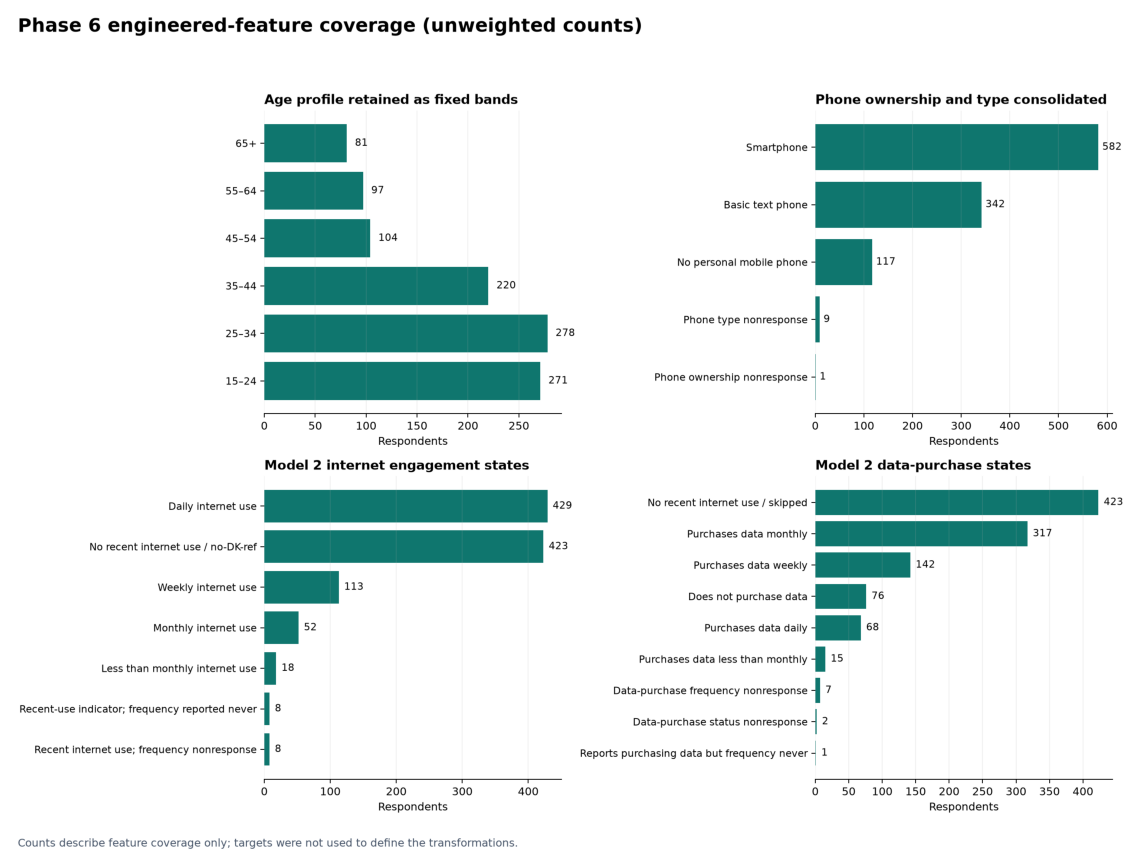

Phase 6 limitations:
• fixed age bands discard within-band age detail
• recent Model 2 digital behaviors overlap the mobile-money target observation period
• internet_use=0 combines no, don't know, and refused
• model usefulness and generalisation remain untested until the dedicated modelling phases


In [4]:
image = mpimg.imread(report_dir / 'figures' / '01_engineered_feature_distributions.png')
plt.figure(figsize=(15, 11))
plt.imshow(image)
plt.axis('off')
plt.show()

print('Phase 6 limitations:')
for limitation in summary['limitations']:
    print(f'• {limitation}')

## Guardrails

The two final matrices are ready for their separate modelling phases. Encoders must still be fitted inside training folds, and no model-performance claim is valid yet.